<a href="https://colab.research.google.com/github/Zeldano118/QPon_NLP_PBA/blob/main/assignments/week%202/2.%20Week2_Preprocessing_QPon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## QPon Apps Review - Preprocessing
Re-run of Week 2 preprocessing notebook using QPon app reviews.

In [ ]:
!pip install google_play_scraper textblob seaborn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.4 MB/s eta 0:00:00


In [ ]:
from google_play_scraper import app
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from nltk.corpus import stopwords
from collections import Counter
import nltk

nltk.download('stopwords', quiet=True)

True

In [ ]:
# load the CSV saved from scrapping notebook
# if running separately, upload df_qpon_rev.csv first
from google.colab import files
uploaded = files.upload()

import io
for fn in uploaded.keys():
    print(f'Uploaded: {fn} ({len(uploaded[fn])} bytes)')
    df = pd.read_csv(io.BytesIO(uploaded[fn]))
    print('Loaded into df')

Saving df_qpon_rev.csv to df_qpon_rev (1).csv
Uploaded: df_qpon_rev (1).csv (2192927 bytes)
Loaded into df


In [ ]:
df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,85c1f968-1c50-4eb0-a84e-c4fdea4ac20d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tidak bisa login (alasan aktivitas mencurigaka...,1,170,2.21.0.1,2026-01-11 13:44:34,NaN,NaN,2.21.0.1
1,36aaf78f-66de-4b14-9adc-21575d7a94a3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"aplikasi log out dengan sendirinya, pas login ...",1,79,2.21.0.1,2026-01-16 05:05:27,NaN,NaN,2.21.0.1
2,9a0b398e-d7b1-4679-a4d4-97f7aa47f9f6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kapok deh Awal doang enak . sekarang2 mau orde...,1,37,2.21.0.1,2026-01-11 04:31:11,NaN,NaN,2.21.0.1
3,113779d5-cae5-49f7-b67d-1a885af6f1fc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,CS gak bisa ngebantu buat login karena masalah...,1,52,2.24.0.1,2026-02-21 04:07:01,NaN,NaN,2.24.0.1
4,1d499b55-883c-422c-a83e-0a181330fd97,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,aplikasi banyak error. perkara ganti hape dibi...,1,2,2.24.0.1,2026-03-10 08:43:02,NaN,NaN,2.24.0.1
...,...,...,...,...,...,...,...,...,...,...,...
4679,4fb306b1-ef25-44fa-aff9-06c517e4f043,siti fatimah,https://play-lh.googleusercontent.com/a/ACg8oc...,murah banget,5,0,NaN,2025-12-06 07:35:17,NaN,NaN,NaN
4680,827f7dc8-944f-4cf4-ac7a-d83302f0767e,Juliant Candra,https://play-lh.googleusercontent.com/a/ACg8oc...,🙏🙏🙏,5,0,NaN,2025-12-13 18:51:40,NaN,NaN,NaN
4681,20d1d5b6-f366-4869-a44c-a993e9e53dec,Uchei Angraeni,https://play-lh.googleusercontent.com/a-/ALV-U...,👍,5,0,NaN,2026-01-17 04:18:45,NaN,NaN,NaN
4682,74dba772-c881-40a4-971f-8a73471cdbba,By-you Creations,https://play-lh.googleusercontent.com/a-/ALV-U...,👎👎👎👎👎👎👎👎👎👎,1,0,NaN,2025-07-03 11:14:34,Terima kasih atas ulasannya. Mohon maaf buat p...,2025-07-07 04:32:27,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4684 entries, 0 to 4683
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              4684 non-null   object
 1   userName              4684 non-null   object
 2   userImage             4684 non-null   object
 3   content               4684 non-null   object
 4   score                 4684 non-null   int64 
 5   thumbsUpCount         4684 non-null   int64 
 6   reviewCreatedVersion  3637 non-null   object
 7   at                    4684 non-null   object
 8   replyContent          2772 non-null   object
 9   repliedAt             2772 non-null   object
 10  appVersion            3637 non-null   object
dtypes: int64(2), object(9)
memory usage: 402.7+ KB


In [ ]:
indonesian_stopwords = set(stopwords.words('indonesian'))

text_column = 'content'
all_text = ' '.join(df[text_column].dropna().astype(str))
words = all_text.lower().split()
filtered_words = [w for w in words if w not in indonesian_stopwords]
word_counts = Counter(filtered_words)
common_words = word_counts.most_common(50)

print('Top 50 words (before full preprocessing):')
common_df = pd.DataFrame(common_words, columns=['word', 'count'])
common_df

Top 50 words (before full preprocessing):


,word,count
0,aplikasi,1366
1,qpon,1059
2,nya,878
3,ga,799
4,voucher,720
5,gak,659
6,yg,655
7,promo,603
8,banget,597
9,beli,519


In [ ]:
df.loc[:, ['content', 'score', 'thumbsUpCount',
           'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt']]

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,tidak bisa login (alasan aktivitas mencurigaka...,1,170,2.21.0.1,2026-01-11 13:44:34,NaN,NaN
1,"aplikasi log out dengan sendirinya, pas login ...",1,79,2.21.0.1,2026-01-16 05:05:27,NaN,NaN
2,kapok deh Awal doang enak . sekarang2 mau orde...,1,37,2.21.0.1,2026-01-11 04:31:11,NaN,NaN
3,CS gak bisa ngebantu buat login karena masalah...,1,52,2.24.0.1,2026-02-21 04:07:01,NaN,NaN
4,aplikasi banyak error. perkara ganti hape dibi...,1,2,2.24.0.1,2026-03-10 08:43:02,NaN,NaN
...,...,...,...,...,...,...,...
4679,murah banget,5,0,NaN,2025-12-06 07:35:17,NaN,NaN
4680,🙏🙏🙏,5,0,NaN,2025-12-13 18:51:40,NaN,NaN
4681,👍,5,0,NaN,2026-01-17 04:18:45,NaN,NaN
4682,👎👎👎👎👎👎👎👎👎👎,1,0,NaN,2025-07-03 11:14:34,Terima kasih atas ulasannya. Mohon maaf buat p...,2025-07-07 04:32:27


## Stopwords Removal
Indonesian Stopwords

In [ ]:
indonesian_stopwords_list = stopwords.words('indonesian')
print(indonesian_stopwords_list[:20])

['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara']


In [ ]:
print(len(indonesian_stopwords_list))

758


In [ ]:
indonesian_stopwords_list

['ada',
 'adalah',
 'adanya',
 'adapun',
 'agak',
 'agaknya',
 'agar',
 'akan',
 'akankah',
 'akhir',
 'akhiri',
 'akhirnya',
 'aku',
 'akulah',
 'amat',
 'amatlah',
 'anda',
 'andalah',
 'antar',
 'antara',
 'antaranya',
 'apa',
 'apaan',
 'apabila',
 'apakah',
 'apalagi',
 'apatah',
 'artinya',
 'asal',
 'asalkan',
 'atas',
 'atau',
 'ataukah',
 'ataupun',
 'awal',
 'awalnya',
 'bagai',
 'bagaikan',
 'bagaimana',
 'bagaimanakah',
 'bagaimanapun',
 'bagi',
 'bagian',
 'bahkan',
 'bahwa',
 'bahwasanya',
 'baik',
 'bakal',
 'bakalan',
 'balik',
 'banyak',
 'bapak',
 'baru',
 'bawah',
 'beberapa',
 'begini',
 'beginian',
 'beginikah',
 'beginilah',
 'begitu',
 'begitukah',
 'begitulah',
 'begitupun',
 'bekerja',
 'belakang',
 'belakangan',
 'belum',
 'belumlah',
 'benar',
 'benarkah',
 'benarlah',
 'berada',
 'berakhir',
 'berakhirlah',
 'berakhirnya',
 'berapa',
 'berapakah',
 'berapalah',
 'berapapun',
 'berarti',
 'berawal',
 'berbagai',
 'berdatangan',
 'beri',
 'berikan',
 'berikut'

/tmp/ipykernel_426/1678710366.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cdf, x='word', y='count', palette='viridis')


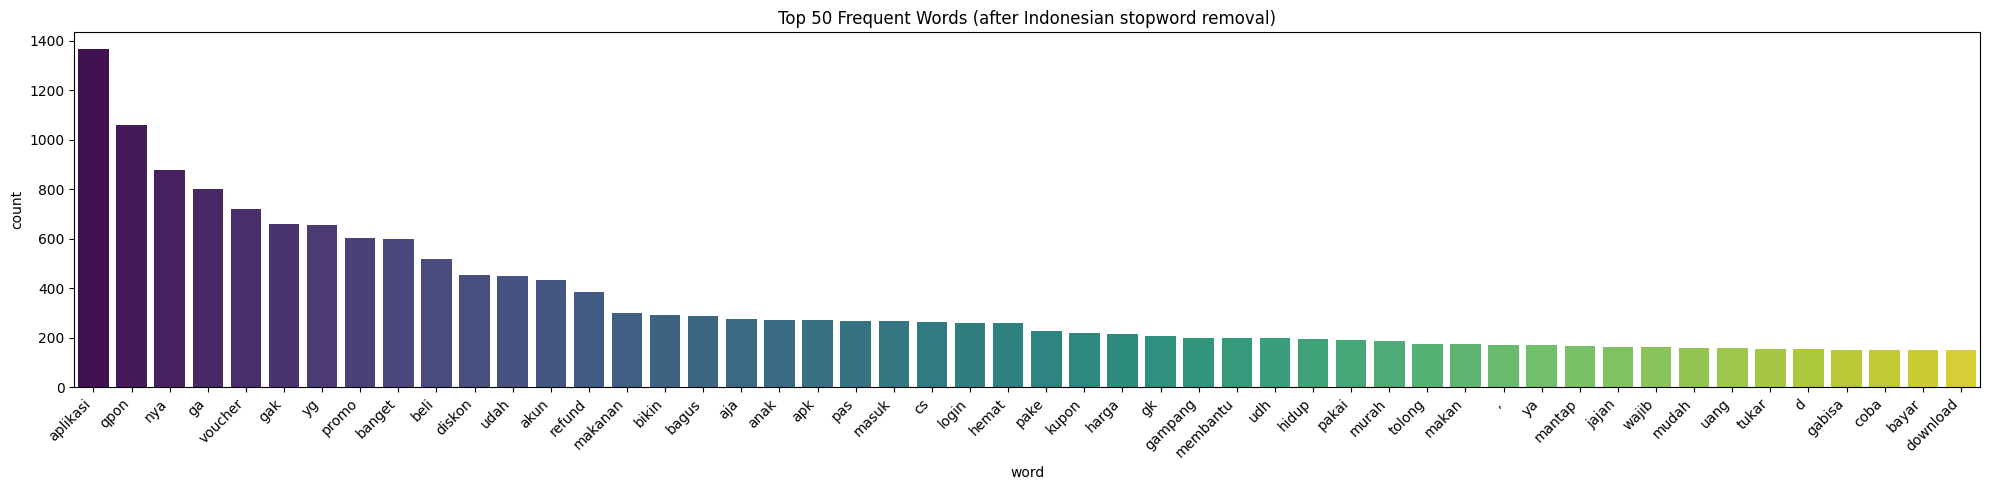

In [ ]:
# most frequent words in content
all_text = ' '.join(df['content'].dropna().astype(str))
words = all_text.lower().split()
filtered = [w for w in words if w not in indonesian_stopwords]
word_counts = Counter(filtered)
common_words = word_counts.most_common(50)

cdf = pd.DataFrame(common_words, columns=['word', 'count'])
plt.figure(figsize=(20, 5))
sns.barplot(data=cdf, x='word', y='count', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Top 50 Frequent Words (after Indonesian stopword removal)')
plt.tight_layout()
plt.show()

In [ ]:
common_words

[('aplikasi', 1366),
 ('qpon', 1059),
 ('nya', 878),
 ('ga', 799),
 ('voucher', 720),
 ('gak', 659),
 ('yg', 655),
 ('promo', 603),
 ('banget', 597),
 ('beli', 519),
 ('diskon', 454),
 ('udah', 448),
 ('akun', 431),
 ('refund', 384),
 ('makanan', 300),
 ('bikin', 292),
 ('bagus', 287),
 ('aja', 277),
 ('anak', 273),
 ('apk', 272),
 ('pas', 266),
 ('masuk', 266),
 ('cs', 262),
 ('login', 260),
 ('hemat', 259),
 ('pake', 226),
 ('kupon', 218),
 ('harga', 216),
 ('gk', 207),
 ('gampang', 200),
 ('membantu', 199),
 ('udh', 197),
 ('hidup', 194),
 ('pakai', 191),
 ('murah', 186),
 ('tolong', 176),
 ('makan', 175),
 (',', 172),
 ('ya', 171),
 ('mantap', 166),
 ('jajan', 164),
 ('wajib', 164),
 ('mudah', 157),
 ('uang', 156),
 ('tukar', 154),
 ('d', 152),
 ('gabisa', 151),
 ('coba', 150),
 ('bayar', 149),
 ('download', 148)]

### Homework Note
From the most frequent words above, informal/meaningless words like `ga`, `gak`, `yg`, `nya`, `udah`, `aja` etc. can be added to the stopword list for better preprocessing.